In [1]:
corpus = ["i love nlp" , 'i teach gen ai ' , 'i am working with euron']

In [2]:
unique_words=list(set(" ".join(corpus).split()))

In [3]:
unique_words

['gen', 'with', 'love', 'i', 'ai', 'teach', 'working', 'euron', 'am', 'nlp']

In [4]:
for i  in enumerate(unique_words):
    print(i)

(0, 'gen')
(1, 'with')
(2, 'love')
(3, 'i')
(4, 'ai')
(5, 'teach')
(6, 'working')
(7, 'euron')
(8, 'am')
(9, 'nlp')


In [5]:
word_to_index = {word:i for i,word  in enumerate(unique_words)}

In [6]:
unique_words

['gen', 'with', 'love', 'i', 'ai', 'teach', 'working', 'euron', 'am', 'nlp']

In [7]:
word_to_index

{'gen': 0,
 'with': 1,
 'love': 2,
 'i': 3,
 'ai': 4,
 'teach': 5,
 'working': 6,
 'euron': 7,
 'am': 8,
 'nlp': 9}

In [8]:
one_hot_vecotor = []

In [9]:
for sentence in corpus:
    print(sentence)
    sentence_vector = []
    for word in sentence.split():
        vector = [0] * len(unique_words)
        print(vector)
        vector[word_to_index[word]] = 1
        sentence_vector.append(vector)
    one_hot_vecotor.append(sentence_vector)

i love nlp
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
i teach gen ai 
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
i am working with euron
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [10]:
print(one_hot_vecotor)

[[[0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], [[0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]], [[0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]]]


In [11]:
l = ["sudh",4,5,6,7,87 , "kumar"]

In [12]:
l[0] = 1

In [13]:
l

[1, 4, 5, 6, 7, 87, 'kumar']

#Bag of words(BoW): Frequency Based Encoding Technique

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

In [16]:
vectorizer = CountVectorizer(stop_words=None,lowercase=False,vocabulary=unique_words)

In [17]:
corpus = ["I love nlp nlp nlp " , 'I teach gen ai gen ai gen ai ' , 'I am working with euron working']

In [18]:
X = vectorizer.fit_transform(corpus)

In [19]:
X.toarray()

array([[0, 0, 1, 0, 0, 0, 0, 0, 0, 3],
       [3, 0, 0, 0, 3, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 2, 1, 1, 0]])

In [20]:
vectorizer.get_feature_names_out()

array(['gen', 'with', 'love', 'i', 'ai', 'teach', 'working', 'euron',
       'am', 'nlp'], dtype=object)

#TF-IDF (Term Frequency - inverse document frequency)

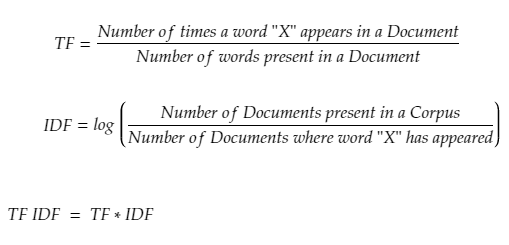

# TF-IDF: Term Frequency and Inverse Document Frequency

TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic used in information retrieval and text mining to evaluate the importance of a word in a document relative to a collection of documents (corpus).

## Term Frequency (TF)

Term Frequency measures how frequently a term appears in a document.

### Formula

$$\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$$

### Variations

- **Raw count**: $\text{TF}(t, d) = f(t, d)$
- **Boolean frequency**: $\text{TF}(t, d) = \begin{cases} 1 & \text{if } t \text{ occurs in } d \\ 0 & \text{otherwise} \end{cases}$
- **Logarithmically scaled**: $\text{TF}(t, d) = \begin{cases} 1 + \log(f(t, d)) & \text{if } f(t, d) > 0 \\ 0 & \text{otherwise} \end{cases}$
- **Augmented frequency**: $\text{TF}(t, d) = 0.5 + 0.5 \times \frac{f(t, d)}{\max\{f(w, d): w \in d\}}$

### Example Calculation

Consider the document: "The cat sat on the mat."

Total terms: 6

| Term | Count | TF |
|------|-------|------|
| the | 2 | 2/6 = 0.33 |
| cat | 1 | 1/6 = 0.17 |
| sat | 1 | 1/6 = 0.17 |
| on | 1 | 1/6 = 0.17 |
| mat | 1 | 1/6 = 0.17 |

## Inverse Document Frequency (IDF)

IDF measures how important a term is by weighing down the frequent terms while scaling up the rare ones.

### Formula

$$\text{IDF}(t, D) = \log\left(\frac{N}{df(t)}\right)$$

Where:
- $N$ is the total number of documents in the corpus
- $df(t)$ is the number of documents containing the term $t$

### Variation with Smoothing

$$\text{IDF}(t, D) = \log\left(\frac{N}{1 + df(t)}\right) + 1$$

### Example Calculation

Consider a corpus of 4 documents:
1. "The cat sat on the mat."
2. "The dog jumped on the bed."
3. "The cat and dog are friends."
4. "My cat likes to sleep."

| Term | Document Frequency (df) | IDF = log(N/df) |
|------|-------------------------|-----------------|
| cat | 3 (docs 1, 3, 4) | log(4/3) ≈ 0.125 |
| the | 3 (docs 1, 2, 3) | log(4/3) ≈ 0.125 |
| sleep | 1 (doc 4) | log(4/1) = log(4) ≈ 0.602 |

## TF-IDF Calculation

TF-IDF is the product of TF and IDF.

### Formula

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

### Example Calculation

For document 1 ("The cat sat on the mat."):

| Term | TF | IDF | TF-IDF |
|------|-----|-----|--------|
| cat | 0.17 | 0.125 | 0.17 × 0.125 = 0.021 |
| the | 0.33 | 0.125 | 0.33 × 0.125 = 0.041 |

For document 4 ("My cat likes to sleep."), assuming 5 terms total:

| Term | TF | IDF | TF-IDF |
|------|-----|-----|--------|
| cat | 0.20 | 0.125 | 0.20 × 0.125 = 0.025 |
| sleep | 0.20 | 0.602 | 0.20 × 0.602 = 0.120 |

The higher TF-IDF score for "sleep" in document 4 compared to "cat" in document 1 indicates that "sleep" is more important or distinctive for its document, despite similar term frequencies. This is because "sleep" appears in fewer documents overall, making it more discriminative.

# TF-IDF Calculation Guide

## 1. Term Frequency (TF)
**Definition:** Measures how often a term appears in a document.

### Formula:

$$\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}
$$

### Example Calculation:
**Document:**  
*"Machine learning is a subset of artificial intelligence. Machine learning algorithms are powerful."*

**Task:** Calculate TF for the term "machine".

1. **Count of "machine" in the document:** 2
2. **Total terms in the document:** 14 (split by spaces and punctuation).

$$
\text{TF("machine", d)} = \frac{2}{14} \approx 0.1429
$$

---

## 2. Inverse Document Frequency (IDF)
**Definition:** Measures how rare a term is across all documents in a corpus.

### Formula:
$$
\text{IDF}(t, D) = \log\left(\frac{\text{Total number of documents in corpus } D}{\text{Number of documents containing term } t}\right)
$$

### Example Calculation:
**Corpus:**  
- Document 1: "Machine learning is powerful."  
- Document 2: "Artificial intelligence is fascinating."  
- Document 3: "Machine learning applications are growing."  

**Task:** Calculate IDF for the term "machine".

1. **Total documents in corpus (N):** 3  
2. **Documents containing "machine":** 2 (Documents 1 and 3).

$$
\text{IDF("machine", D)} = \log\left(\frac{3}{2}\right) \approx 0.1761
$$

---

## 3. TF-IDF Score
**Definition:** Combines TF and IDF to weigh the importance of a term in a document relative to the corpus.

### Formula:
\[
\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)
\]

### Example Calculation (Continued):
Using the values from above:


$$\text{TF-IDF("machine", d, D)} = 0.1429 \times 0.1761 \approx 0.0252$$


---

## Key Notes:
- **Higher TF-IDF** means the term is **important in the document** and **rare in the corpus**.
- **Stopwords** (e.g., "is", "are") have low TF-IDF due to high IDF (common across documents).
- **Logarithm base:** Typically base 10 or natural logarithm (base \(e\)), but the base choice depends on convention.

---

## Practical Example Table
| Term       | TF (in document) | IDF (in corpus) | TF-IDF Score |
|------------|------------------|-----------------|-------------|
| "machine"  | 0.1429           | 0.1761          | 0.0252      |
| "learning" | 0.1429           | 0.3010          | 0.0429      |

---

## Why Use TF-IDF?
- **Highlights important terms** (e.g., "machine learning" in technical documents).
- **Reduces the weight of common words** (e.g., "the", "is").
- Widely used in search engines, text classification, and NLP tasks.

---

## Code Snippet (Python)
```python
import math

def tf(term, doc):
    return doc.lower().split().count(term.lower()) / len(doc.split())

def idf(term, corpus):
    num_docs_with_term = sum(1 for doc in corpus if term.lower() in doc.lower())
    return math.log(len(corpus) / num_docs_with_term)

def tf_idf(term, doc, corpus):
    return tf(term, doc) * idf(term, corpus)

# Example usage
document = "Machine learning is a subset of AI. Machine learning is powerful."
corpus = [
    "Machine learning is powerful.",
    "AI and robotics are advancing.",
    "Machine learning applications are growing."
]

print(tf_idf("machine", document, corpus))  # Output: ~0.0252

---

## Summary
- **TF** focuses on **local relevance** (within a document).  
- **IDF** focuses on **global rarity** (across the corpus).  
- **TF-IDF** balances both to prioritize meaningful terms.
```

This version emphasizes clarity and step-by-step calculations while maintaining brevity. It uses LaTeX equations, tables, and code snippets for practical understanding. The example uses a different term ("machine") to avoid repetition from prior examples, ensuring fresh context.

In [23]:
corpus

['I love nlp nlp nlp ',
 'I teach gen ai gen ai gen ai ',
 'I am working with euron working']

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
vect_tf_idf = TfidfVectorizer()

In [26]:
X = vect_tf_idf.fit_transform(corpus)

In [27]:
X.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.31622777,
        0.9486833 , 0.        , 0.        , 0.        ],
       [0.6882472 , 0.        , 0.        , 0.6882472 , 0.        ,
        0.        , 0.22941573, 0.        , 0.        ],
       [0.        , 0.37796447, 0.37796447, 0.        , 0.        ,
        0.        , 0.        , 0.37796447, 0.75592895]])